# What is an Ordinary Differential Equation?

## Visualisation Through Vector Fields & Initial Value Problems

This notebook answers a deceptively simple question:
*what does an ODE actually look like?*

We will see that an ODE

$$
\frac{dy}{dt} = f(t,\,y)
$$

defines a **vector field** — a little arrow (slope) at every point $(t, y)$
in the plane — and that solving the ODE means finding a curve
$y(t)$ that is *tangent to every arrow it passes through*.

### What you will learn

| Concept | Key idea |
|---------|----------|
| Vector field | An ODE assigns a slope to every point in the $(t, y)$ plane |
| Initial Value Problem (IVP) | A starting point $(t_0, y_0)$ picks *one* curve from infinitely many |
| Autonomous vs. non-autonomous | Does $f$ depend on $t$, on $y$, or on both? |
| Numerical solution | `scipy.integrate.solve_ivp` (RK45) traces the curve |

---

## 1 — Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 2 — The Core Idea: an ODE is a Vector Field

Consider the ODE

$$
\frac{dy}{dt} = -0.5\,y + \cos(t)
$$

The right-hand side $f(t, y) = -0.5\,y + \cos(t)$ is a function
of **two** variables. At every point $(t, y)$ it returns a number:
the *slope* that a solution passing through that point must have.

If we draw a small arrow with that slope at many points in the
$(t, y)$ plane, we get the **vector field** (also called
*direction field* or *slope field*).

In [19]:
def plot_vector_field(f, t_range=(-5, 5), y_range=(-5, 5), n=20,
                      ax=None, title=None):
    """
    Draw the vector field of dy/dt = f(t, y).

    Each arrow points in the direction (1, f(t,y)), normalised
    to equal length so the *direction* is visible, not the magnitude.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    t_vals = np.linspace(*t_range, n)
    y_vals = np.linspace(*y_range, n)
    T, Y = np.meshgrid(t_vals, y_vals)

    dT = np.ones_like(T)              # horizontal component = 1
    dY = f(T, Y)                      # vertical component = slope

    # Normalise to unit length (direction only)
    norm = np.sqrt(dT**2 + dY**2)
    dT /= norm
    dY /= norm

    ax.quiver(T, Y, dT, dY, color="#9ca3af", scale=35,
              headwidth=4, headlength=5, alpha=0.7)
    ax.set_xlabel("$t$")
    ax.set_ylabel("$y$")
    ax.set_xlim(t_range)
    ax.set_ylim(y_range)
    if title:
        ax.set_title(title, fontweight="bold")
    return ax

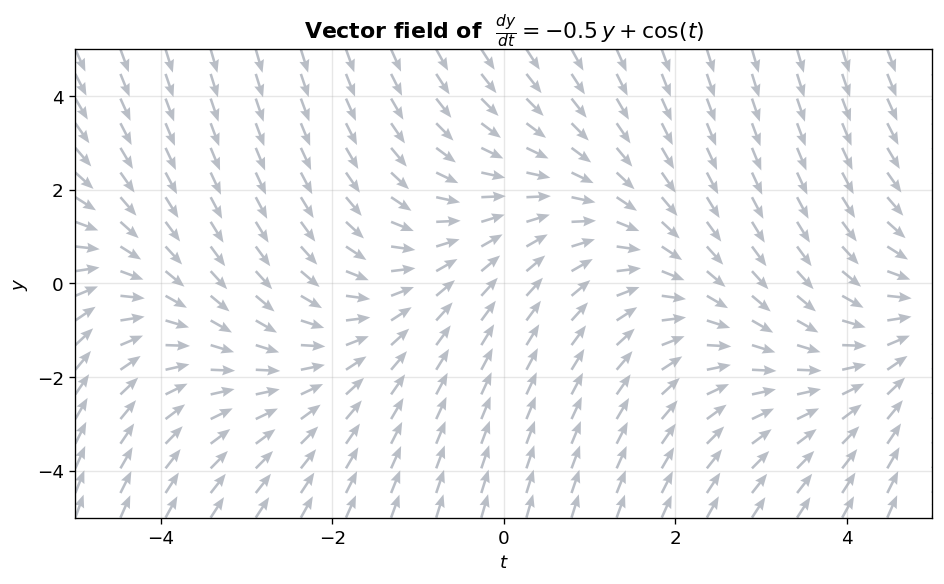

In [20]:
# Our first ODE
f = lambda t, y: -0.5 * y + np.cos(t)

fig, ax = plt.subplots(figsize=(8, 5))
plot_vector_field(f, ax=ax,
    title=r"Vector field of  $\frac{dy}{dt} = -0.5\,y + \cos(t)$")
fig.tight_layout()
plt.show()

Every grey arrow shows which direction a solution must travel if
it passes through that point. But which *specific* curve does the
solution follow? That depends on where it **starts**.

## 3 — The Initial Value Problem (IVP)

An ODE on its own has **infinitely many** solutions — one for every
possible starting point. To pick a single, unique solution we must
specify an **initial condition**:

$$
\frac{dy}{dt} = f(t, y), \qquad y(t_0) = y_0
$$

This pair (ODE + initial condition) is called an
**Initial Value Problem (IVP)**. The solution is the curve that
starts at $(t_0, y_0)$ and follows the arrows.

In [21]:
def solve_and_plot(f, t0, y0, t_end, ax, color="#ef4444", label=None):
    """
    Solve the IVP  dy/dt = f(t,y), y(t0) = y0  using RK45,
    integrating FORWARD from t0 to t_end.

    The solution starts at the initial condition (green dot)
    and flows in the direction dictated by the vector field.
    """
    sol = solve_ivp(
        fun    = lambda t, y: [f(t, y[0])],
        t_span = (t0, t_end),
        y0     = [y0],
        method = "RK45",
        t_eval = np.linspace(t0, t_end, 500),
        rtol   = 1e-8,
    )
    ax.plot(sol.t, sol.y[0], color=color, lw=2.5, label=label, zorder=4)
    # Mark the STARTING point
    ax.plot(t0, y0, "o", color=color, markersize=8, zorder=5,
            markeredgecolor="white", markeredgewidth=1.5)
    return sol


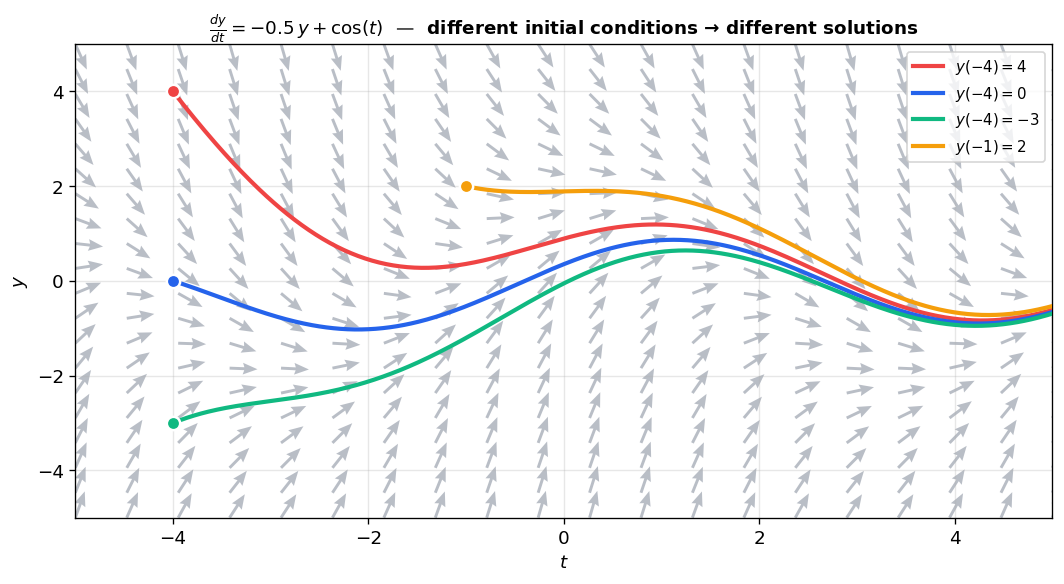

In [22]:
# Same vector field — but different starting points
f = lambda t, y: -0.5 * y + np.cos(t)

fig, ax = plt.subplots(figsize=(9, 5))
plot_vector_field(f, ax=ax)

# Each solution STARTS at the dot and flows forward in time
initial_conditions = [
    (-4,  4.0, "#ef4444", "$y(-4) = 4$"),
    (-4,  0.0, "#2563eb", "$y(-4) = 0$"),
    (-4, -3.0, "#10b981", "$y(-4) = -3$"),
    (-1,  2.0, "#f59e0b", "$y(-1) = 2$"),
]

for t0, y0, col, lab in initial_conditions:
    solve_and_plot(f, t0, y0, t_end=5, ax=ax, color=col, label=lab)

ax.legend(fontsize=9, loc="upper right")
ax.set_title(
    r"$\frac{dy}{dt} = -0.5\,y + \cos(t)$"
    "  —  different initial conditions → different solutions",
    fontsize=11, fontweight="bold",
)
fig.tight_layout()
plt.show()


Each coloured curve **starts** at the dot (the initial condition)
and flows forward in time, always tangent to the grey arrows.

Notice how all solutions are eventually attracted toward the
same oscillating pattern — this is because the $-0.5\,y$ term
acts as a damping force. The choice of starting point only
affects the *transient* behaviour.

## 4 — Classification: What Does $f$ Depend On?

The structure of the vector field changes dramatically depending
on which variables appear in $f$.

| Type | Form | Vector field pattern |
|------|------|---------------------|
| **Time-dependent only** | $f(t)$ | All arrows on a vertical line ($t$ = const) have the **same** slope |
| **Autonomous** | $f(y)$ | All arrows on a horizontal line ($y$ = const) have the **same** slope |
| **General** | $f(t, y)$ | Slopes change in both directions — no simple symmetry |

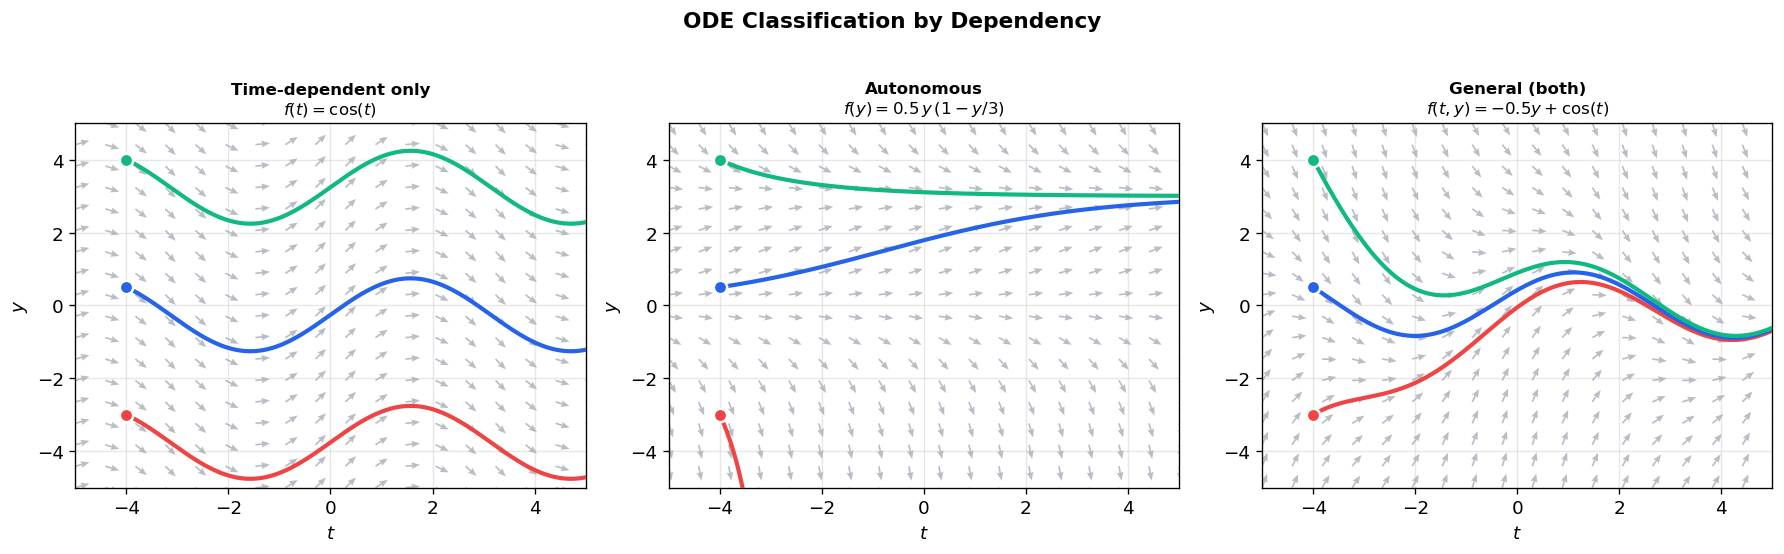

In [23]:
odes = [
    (r"$f(t)  = \cos(t)$",           lambda t, y: np.cos(t),            "Time-dependent only"),
    (r"$f(y)  = 0.5\,y\,(1 - y/3)$", lambda t, y: 0.5*y*(1 - y/3),    "Autonomous"),
    (r"$f(t,y) = -0.5y + \cos(t)$",  lambda t, y: -0.5*y + np.cos(t), "General (both)"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (formula, f_ode, category) in zip(axes, odes):
    plot_vector_field(f_ode, ax=ax, n=18)

    # Solutions start at t=-4 and flow forward
    for y0, col in [(-3, "#ef4444"), (0.5, "#2563eb"), (4, "#10b981")]:
        solve_and_plot(f_ode, t0=-4, y0=y0, t_end=5, ax=ax, color=col)

    ax.set_title(f"{category}\n{formula}", fontsize=10, fontweight="bold")

fig.suptitle("ODE Classification by Dependency",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


Look closely:

- **Left panel** — all arrows on any vertical line point in the same
  direction (the slope depends only on $t$).
- **Centre panel** — all arrows on any horizontal line point in the
  same direction (the slope depends only on $y$). The line $y = 3$ is
  an **equilibrium** where $f(y) = 0$.
- **Right panel** — the arrows change in both directions.

## 5 — Equilibria and Stability (Autonomous Case)

For an autonomous ODE $\frac{dy}{dt} = f(y)$, the points where
$f(y^*) = 0$ are called **equilibria** (or fixed points).
The solution $y(t) = y^*$ is constant — a horizontal line.

An equilibrium is **stable** if nearby solutions converge toward it,
and **unstable** if they diverge away.

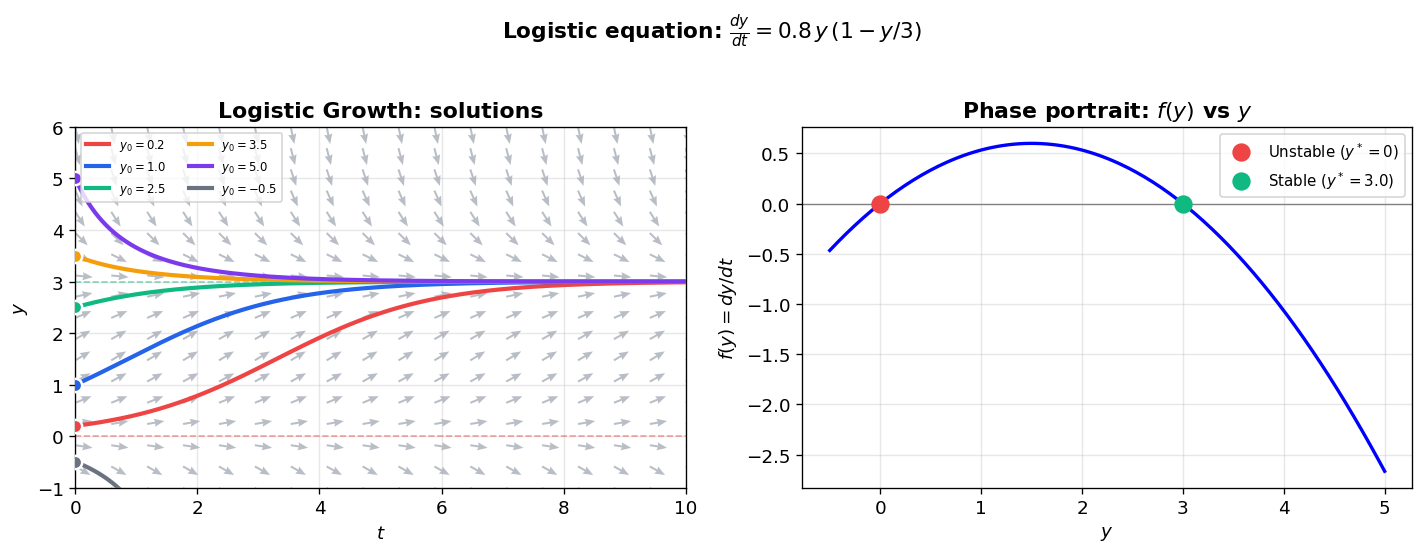

In [24]:
# Logistic growth:  dy/dt = r*y*(1 - y/K)
# Equilibria at y=0 (unstable) and y=K (stable)
r, K = 0.8, 3.0
f_logistic = lambda t, y: r * y * (1 - y / K)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: vector field + solutions starting at t=0, flowing forward
plot_vector_field(f_logistic, t_range=(0, 10), y_range=(-1, 6), ax=ax1, n=18)

for y0, col in [(0.2, "#ef4444"), (1.0, "#2563eb"), (2.5, "#10b981"),
                (3.5, "#f59e0b"), (5.0, "#7c3aed"), (-0.5, "#6b7280")]:
    solve_and_plot(f_logistic, t0=0, y0=y0, t_end=10, ax=ax1, color=col,
                   label=f"$y_0 = {y0}$")

ax1.axhline(K, color="#10b981", ls="--", lw=1, alpha=0.5)
ax1.axhline(0, color="#ef4444", ls="--", lw=1, alpha=0.5)
ax1.legend(fontsize=7, ncol=2, loc="upper left")
ax1.set_title("Logistic Growth: solutions", fontweight="bold")

# Right: phase line f(y) vs y
y_vals = np.linspace(-0.5, 5, 200)
ax2.plot(y_vals, f_logistic(0, y_vals), "b-", lw=2)
ax2.axhline(0, color="grey", lw=0.8)
ax2.plot(0, 0, "o", color="#ef4444", markersize=10, label="Unstable ($y^*=0$)")
ax2.plot(K, 0, "o", color="#10b981", markersize=10, label=f"Stable ($y^*={K}$)")
ax2.set_xlabel("$y$")
ax2.set_ylabel("$f(y) = dy/dt$")
ax2.set_title(r"Phase portrait: $f(y)$ vs $y$", fontweight="bold")
ax2.legend(fontsize=9)

fig.suptitle(
    r"Logistic equation: $\frac{dy}{dt} = 0.8\,y\,(1 - y/3)$",
    fontsize=13, fontweight="bold", y=1.02,
)
fig.tight_layout()
plt.show()


## 6 — Gallery of ODEs

A small gallery showing how different right-hand sides $f(t,y)$
create very different vector fields and solution families.

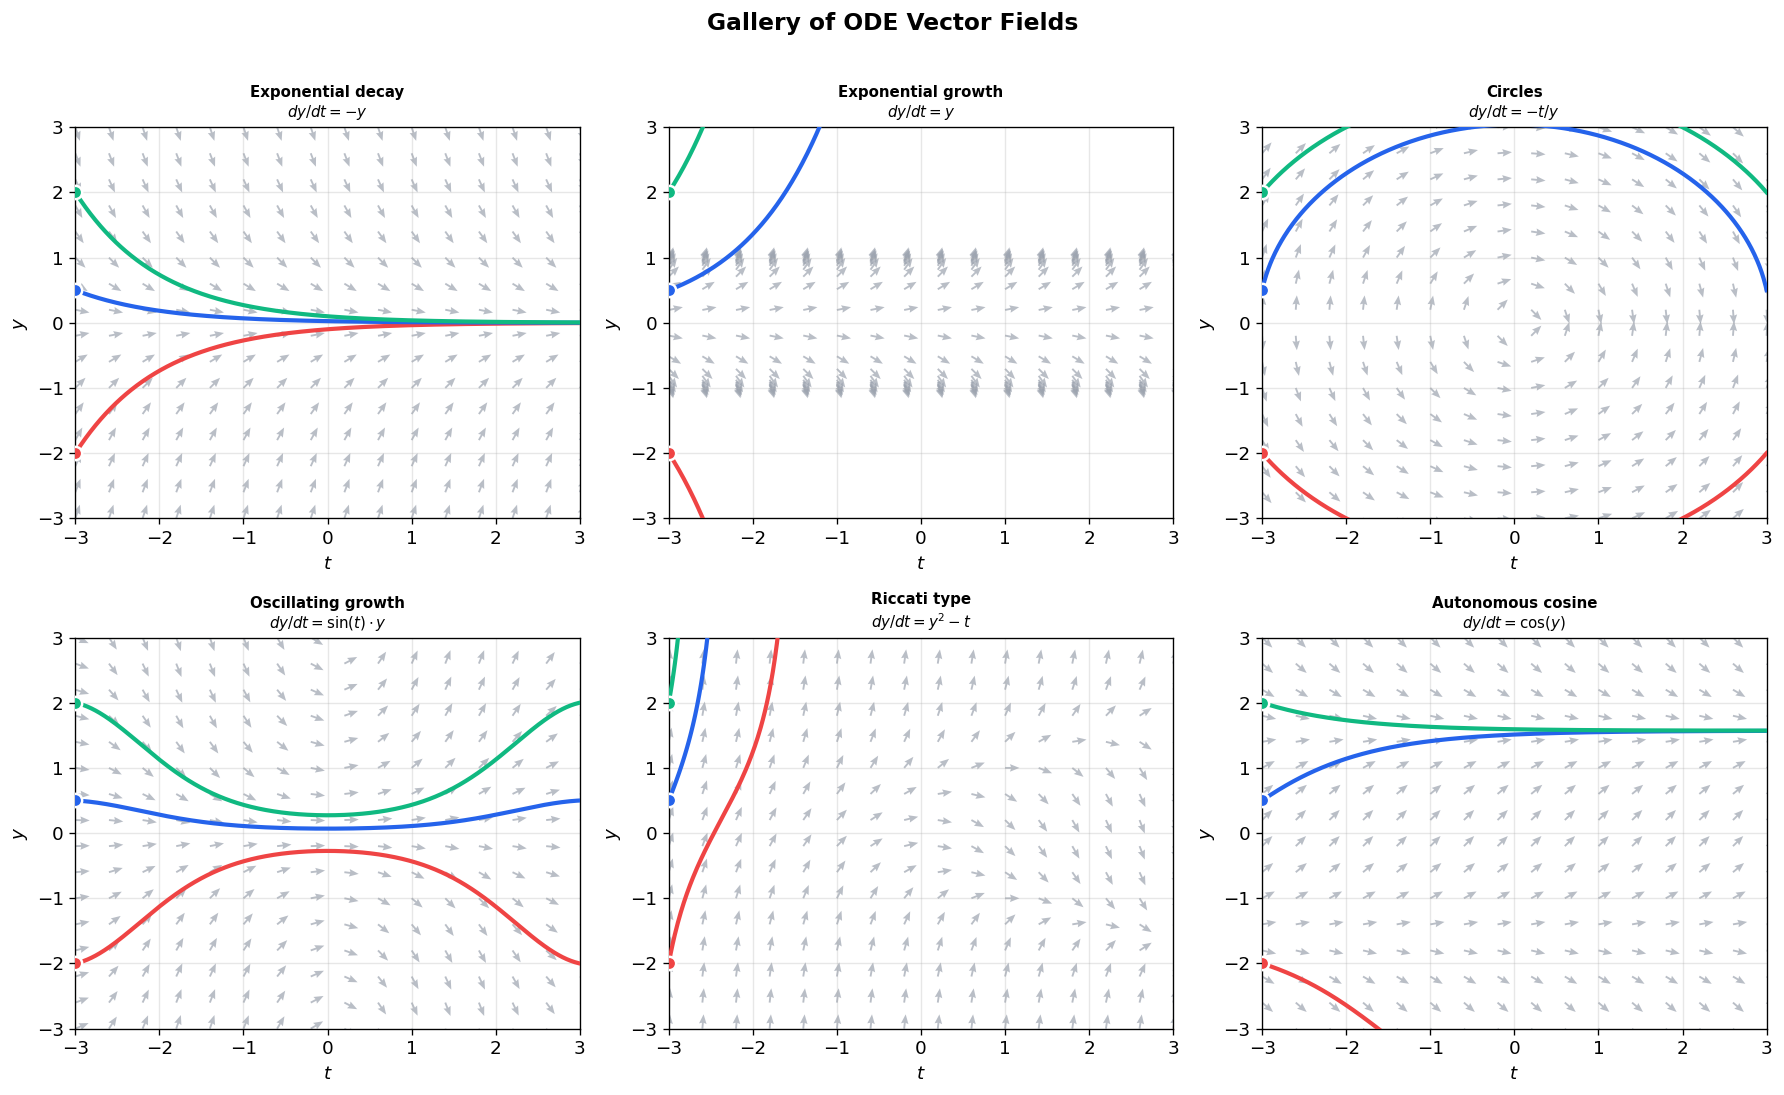

In [25]:
gallery = [
    (r"$dy/dt = -y$",              lambda t, y: -y,                       "Exponential decay"),
    (r"$dy/dt = y$",               lambda t, y: y,                        "Exponential growth"),
    (r"$dy/dt = -t/y$",            lambda t, y: -t / (y + 1e-10),        "Circles"),
    (r"$dy/dt = \sin(t)\cdot y$",  lambda t, y: np.sin(t) * y,           "Oscillating growth"),
    (r"$dy/dt = y^2 - t$",         lambda t, y: y**2 - t,                "Riccati type"),
    (r"$dy/dt = \cos(y)$",         lambda t, y: np.cos(y),               "Autonomous cosine"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (formula, f_ode, desc) in zip(axes.flat, gallery):
    plot_vector_field(f_ode, t_range=(-3, 3), y_range=(-3, 3),
                      ax=ax, n=16)
    for y0, col in [(-2, "#ef4444"), (0.5, "#2563eb"), (2, "#10b981")]:
        try:
            solve_and_plot(f_ode, t0=-3, y0=y0, t_end=3, ax=ax, color=col)
        except Exception:
            pass   # some ODEs blow up for certain ICs
    ax.set_title(f"{desc}\n{formula}", fontsize=9, fontweight="bold")

fig.suptitle("Gallery of ODE Vector Fields",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


## 7 — Under the Hood: How the Solver Works

We used `scipy.integrate.solve_ivp` with `method='RK45'`.
At its core, the solver takes **small steps** along the vector field,
using the slope to predict where to go next.

The simplest version is **Euler's method**:

$$
y_{n+1} = y_n + h \cdot f(t_n,\, y_n)
$$

Let's compare Euler (what your React app uses) with RK45.

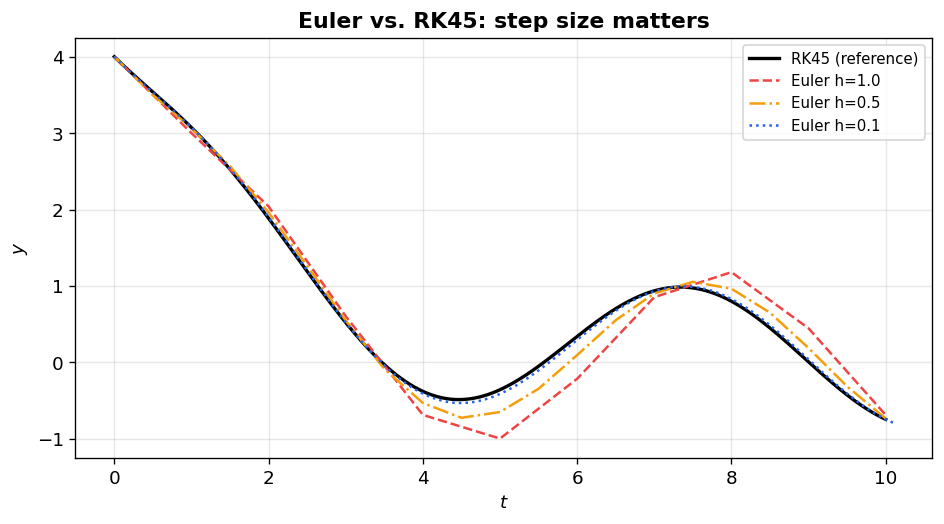

In [26]:
def euler(f, t0, y0, t_end, h):
    """Simple forward Euler method."""
    ts = [t0]
    ys = [y0]
    t, y = t0, y0
    while t < t_end:
        y = y + h * f(t, y)
        t = t + h
        ts.append(t)
        ys.append(y)
    return np.array(ts), np.array(ys)


# Compare on  dy/dt = -0.5*y + cos(t),  y(0) = 4
f = lambda t, y: -0.5 * y + np.cos(t)

fig, ax = plt.subplots(figsize=(8, 4.5))

# RK45 (high accuracy reference)
sol = solve_ivp(lambda t, y: [f(t, y[0])], (0, 10), [4.0],
                method="RK45", t_eval=np.linspace(0, 10, 500), rtol=1e-10)
ax.plot(sol.t, sol.y[0], "k-", lw=2, label="RK45 (reference)")

# Euler with different step sizes
for h, col, ls in [(1.0, "#ef4444", "--"), (0.5, "#f59e0b", "-."),
                    (0.1, "#2563eb", ":")]:
    ts, ys = euler(f, 0, 4.0, 10, h)
    ax.plot(ts, ys, color=col, ls=ls, lw=1.5, label=f"Euler h={h}")

ax.set_xlabel("$t$")
ax.set_ylabel("$y$")
ax.legend(fontsize=9)
ax.set_title("Euler vs. RK45: step size matters", fontweight="bold")
fig.tight_layout()
plt.show()

With a coarse step ($h=1$), Euler visibly drifts. RK45 uses an
**adaptive** step size internally, achieving high accuracy
with far fewer function evaluations.

## 8 — Try Your Own ODE

Change `my_f` below to explore any ODE you like.

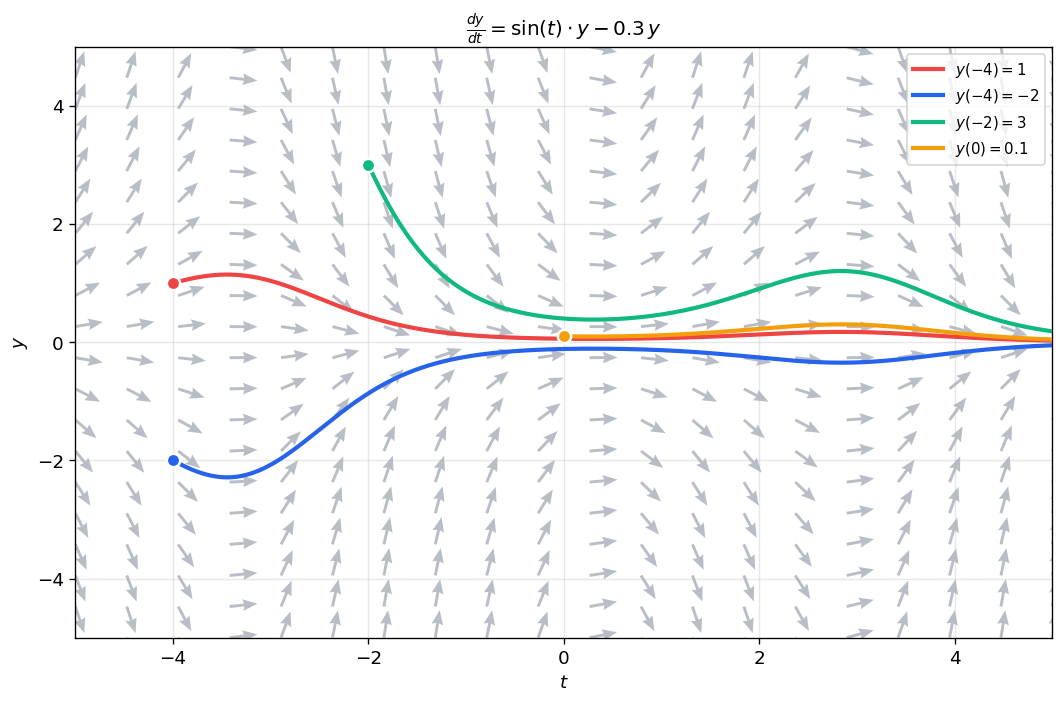

In [27]:
# ============================================================
#   CHANGE THIS to explore any ODE you want
# ============================================================
my_f = lambda t, y: np.sin(t) * y - 0.3 * y
my_title = r"$\frac{dy}{dt} = \sin(t) \cdot y - 0.3\,y$"

t_range = (-5, 5)
y_range = (-5, 5)
start_points = [(-4, 1), (-4, -2), (-2, 3), (0, 0.1)]
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))
plot_vector_field(my_f, t_range=t_range, y_range=y_range, ax=ax, n=20)

colors = ["#ef4444", "#2563eb", "#10b981", "#f59e0b"]
for (t0, y0), col in zip(start_points, colors):
    solve_and_plot(my_f, t0, y0, t_end=5, ax=ax, color=col,
                   label=f"$y({t0}) = {y0}$")

ax.legend(fontsize=9)
ax.set_title(my_title, fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


## 9 — Notes for Students

### Key take-aways

1. **An ODE is a vector field** — The equation $dy/dt = f(t, y)$
   assigns a slope (direction) to every point in the plane.
   A solution is a curve that follows these directions.

2. **An IVP picks one solution** — Without a starting point, an ODE
   has infinitely many solutions. The initial condition
   $y(t_0) = y_0$ selects exactly one.

3. **Autonomous ODEs have special symmetry** — If $f$ depends only
   on $y$, the vector field is the same at every $t$-value,
   and solutions are just time-shifted copies of each other.

4. **Equilibria** — For autonomous ODEs, points where $f(y^*) = 0$
   are equilibria. Stable equilibria attract nearby solutions;
   unstable ones repel them.

5. **Numerical solvers step along the field** — Euler's method
   takes straight-line steps; RK45 uses a smarter multi-stage
   approach with adaptive step sizes for much higher accuracy.

### Exercises

1. Plot the vector field of $dy/dt = y(1-y)(y-2)$. Find all
   equilibria and classify each as stable or unstable by
   inspecting the field or the sign of $f'(y^*)$.

2. For the ODE $dy/dt = -y + \sin(t)$, solve the IVP with
   $y(0) = 0$ analytically (hint: integrating factor). Plot
   the exact solution on top of the numerical one.

3. Implement the **classical RK4** method (not adaptive) and
   compare its accuracy to Euler for the same step size $h$.

4. Explore $dy/dt = y^2$ with $y(0) = 1$. What happens near
   $t = 1$? This is a **blow-up** — the solution goes to infinity
   in finite time.

5. Create a 2D system: $dx/dt = -y$, $dy/dt = x$ (circular motion).
   Plot the vector field in the $(x, y)$ *phase plane* using
   `plt.quiver`.